# Steel rebar physical-market prices

This notebook reads the immutable IME rebar raw CSV and the reproducible A3 / 12 mm daily derived dataset. It plots daily volume-weighted **cash trade price** (`Price`) and **offer-base price** (`ArzeBasePrice`) for that working scope. Dates remain in the source Jalali calendar.

> **Important:** the chart scope is plainly specified straight A3 / 12 mm rebar under cash or cash-matching contracts. It is still exploratory—not an approved comparable-rebar benchmark—because producer, delivery, standard and quotation-basis comparability remain to be validated. The source `Unit` records traded quantity (tonnes).

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT = Path.cwd().resolve().parent
WORKSPACE = PROJECT.parents[1]
if str(WORKSPACE) not in sys.path:
    sys.path.insert(0, str(WORKSPACE))

from shared.ime_data.ime_physical_collector import normalize_fa

RAW_PATH = PROJECT / 'data' / 'raw' / 'physical' / 'rebar_physical_raw.csv'
A3_12_DAILY_PATH = PROJECT / 'data' / 'processed' / 'physical' / 'rebar_a3_12_cash_daily.csv'
FIGURE_PATH = PROJECT / 'outputs' / 'figures' / 'rebar_cash_vs_offer_base_price.png'
RAW_PATH

WindowsPath('C:/Work/commodity/rebar/data/raw/physical/rebar_physical_raw.csv')

In [2]:
if not RAW_PATH.exists():
    raise FileNotFoundError(f'Run the physical collector first: {RAW_PATH}')

raw = pd.read_csv(RAW_PATH, encoding='utf-8-sig', low_memory=False)
for column in ['Price', 'ArzeBasePrice', 'Quantity']:
    raw[column] = pd.to_numeric(
        raw[column].astype(str).str.replace(',', '', regex=False), errors='coerce'
    )

raw['trade_date_jalali'] = raw['date'].astype(str).str.replace('-', '/', regex=False)
raw['contract_type_normalized'] = raw['ContractType'].map(normalize_fa)
from commodity.rebar.src.rebar.processing.rebar_scope import CASH_CONTRACTS

cash_contracts = CASH_CONTRACTS
cash = raw.loc[raw['contract_type_normalized'].isin(cash_contracts)].copy()
cash = cash.loc[
    cash['Quantity'].gt(0) & cash['Price'].gt(0) & cash['ArzeBasePrice'].gt(0)
].copy()

assert cash['trade_date_jalali'].notna().all()
assert cash['Quantity'].gt(0).all()
assert cash['Price'].gt(0).all()
assert cash['ArzeBasePrice'].gt(0).all()

print(f'Raw rows: {len(raw):,}')
print(f'Eligible cash rows: {len(cash):,}')
print(f'Jalali coverage: {cash.trade_date_jalali.min()} to {cash.trade_date_jalali.max()}')
print('Source quantity units:', sorted(raw['Unit'].dropna().astype(str).unique()))

Raw rows: 31,532
Eligible cash rows: 6,894
Jalali coverage: 1387/06/03 to 1405/06/01
Source quantity units: ['تن']


In [3]:
from commodity.rebar.src.rebar.processing.rebar_scope import is_a3_12_straight_rebar

a3_12_source = raw.loc[
    raw['GoodsName'].map(is_a3_12_straight_rebar)
    & raw['contract_type_normalized'].isin(cash_contracts)
    & raw['Quantity'].gt(0)
    & raw['Price'].gt(0)
    & raw['ArzeBasePrice'].gt(0)
].copy()

assert not a3_12_source.empty
assert a3_12_source['GoodsName'].map(is_a3_12_straight_rebar).all()
assert a3_12_source['contract_type_normalized'].isin(cash_contracts).all()
print(f'Strict A3 / 12 mm source rows selected before aggregation: {len(a3_12_source):,}')
print(f'Cash-trade dates before aggregation: {a3_12_source.trade_date_jalali.nunique():,}')
a3_12_source[['GoodsName', 'Symbol', 'ProducerName', 'ContractType']].value_counts().head(20)

Strict A3 / 12 mm source rows selected before aggregation: 307
Cash-trade dates before aggregation: 185


GoodsName     Symbol            ProducerName                               ContractType
میلگرد 12-A3  SJS-LRNNEA3B-00   جهان فولاد سیرجان                          نقدی            77
              HSSC-LRNNEA3B-00  ذوب آهن و تولید میلگرد سیرجان حدید جنوب    نقدی            53
                                                                           نقدی (مچینگ)    39
              NSIC-LRNNEA3B-00  صنایع فولاد نگین اردکان                    نقدی            24
              SJS-LRNNEA3B-00   جهان فولاد سیرجان                          نقدی (مچینگ)    22
              KFAC-LRNNEA3B-00  کیان فولاد ابهر                            نقدی             9
              ESC-LRNNEA3B-00   ذوب آهن اصفهان                             نقدی             8
              SHS-LRNNEA3B-00   فولاد شاهرود                               نقدی             7
              KSRC-LRNNEA3B-00  مجتمع ذوب آهن و نورد کرمان                 نقدی             6
              AAIM-LRNNEA3B-00  ذوب آهن آرمان آسیا                

<>:3: SyntaxWarning: invalid escape sequence '\c'
<>:3: SyntaxWarning: invalid escape sequence '\c'
C:\Users\User\AppData\Local\Temp\ipykernel_19496\3645392552.py:3: SyntaxWarning: invalid escape sequence '\c'
  'Build the selected scope first: python .\commodity\rebar\src\rebar\processing\build_a3_12_cash_daily.py'


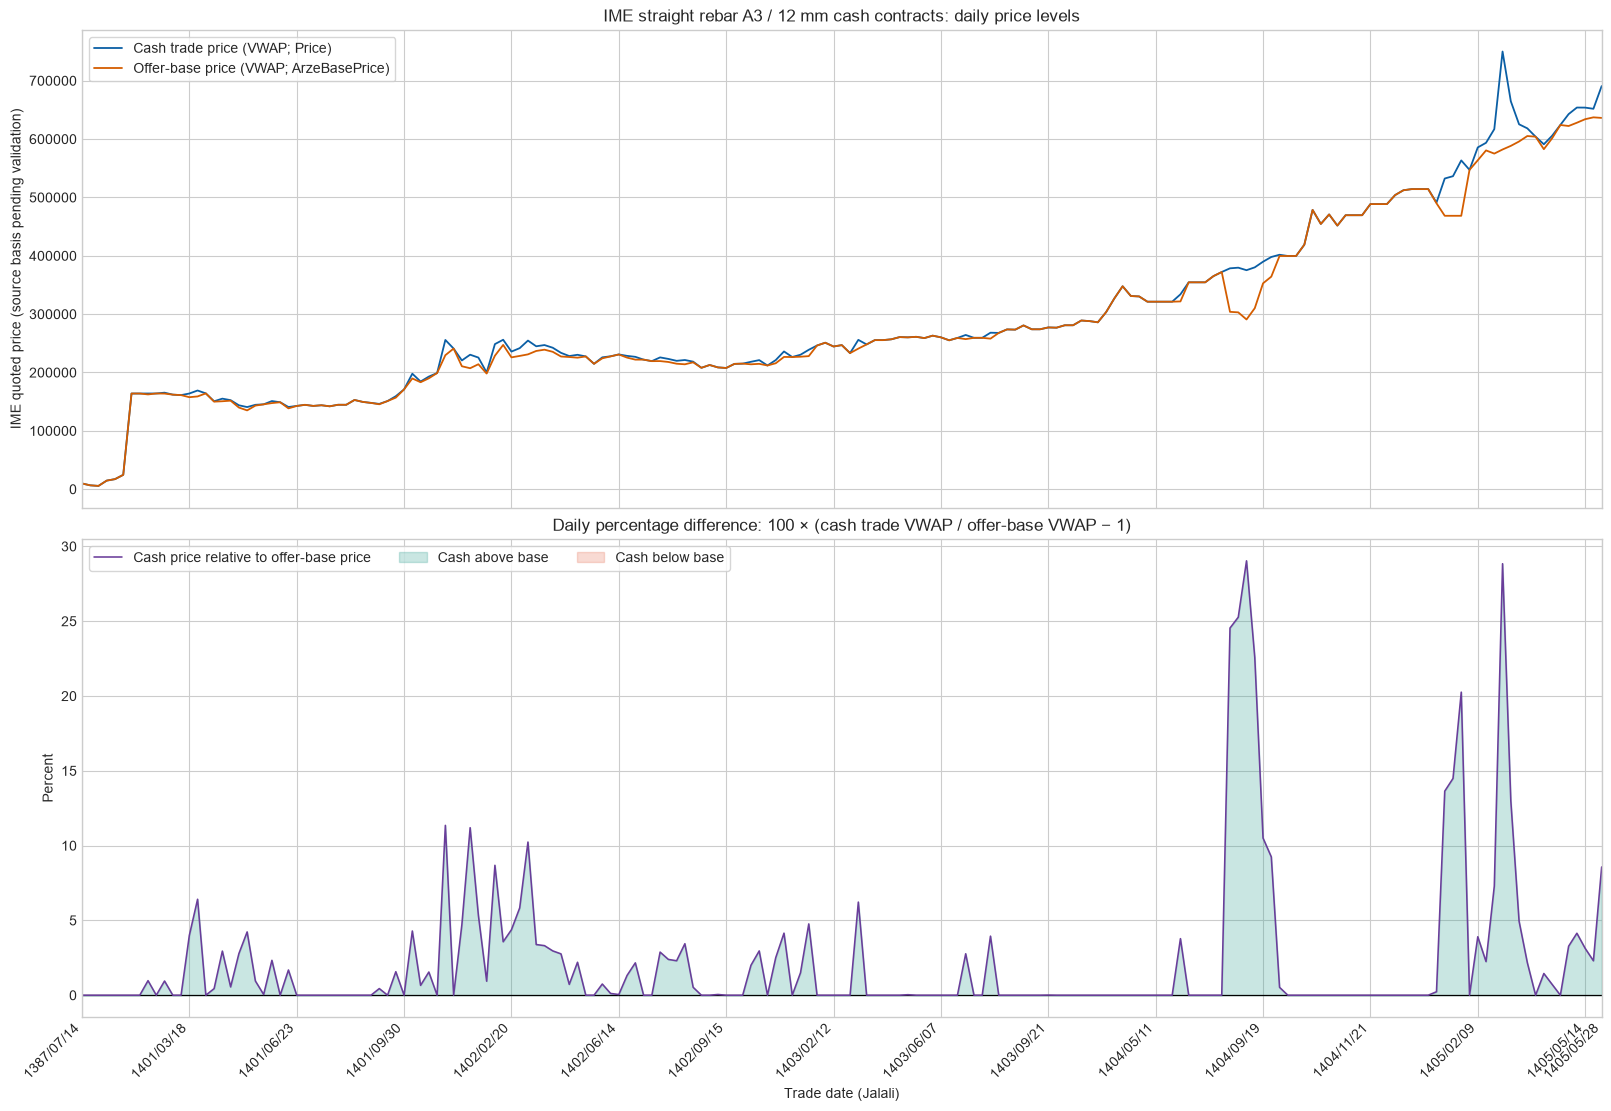

A3 / 12 mm cash dates: 185
Median daily gap: 0.00%
Saved: C:\Work\commodity\rebar\outputs\figures\rebar_cash_vs_offer_base_price.png


In [4]:
if not A3_12_DAILY_PATH.exists():
    raise FileNotFoundError(
        'Build the selected scope first: python .\commodity\rebar\src\rebar\processing\build_a3_12_cash_daily.py'
    )
a3_12_daily = pd.read_csv(A3_12_DAILY_PATH, encoding='utf-8-sig')
assert a3_12_daily['trade_date_jalali'].is_unique
assert a3_12_daily['traded_quantity'].gt(0).all()

plt.style.use('seaborn-v0_8-whitegrid')
fig, (price_ax, gap_ax) = plt.subplots(2, 1, figsize=(16, 11), sharex=True, constrained_layout=True)
ticks = list(range(0, len(a3_12_daily), max(1, len(a3_12_daily) // 14)))
if ticks[-1] != len(a3_12_daily) - 1:
    ticks.append(len(a3_12_daily) - 1)

price_ax.plot(
    a3_12_daily['trade_date_jalali'], a3_12_daily['cash_trade_price_vwap'],
    color='#0b5fa5', linewidth=1.3, label='Cash trade price (VWAP; Price)'
)
price_ax.plot(
    a3_12_daily['trade_date_jalali'], a3_12_daily['offer_base_price_vwap'],
    color='#d45d00', linewidth=1.3, label='Offer-base price (VWAP; ArzeBasePrice)'
)
price_ax.set_title('IME straight rebar A3 / 12 mm cash contracts: daily price levels')
price_ax.set_ylabel('IME quoted price (source basis pending validation)')
price_ax.legend(frameon=True)
price_ax.margins(x=0)

gap_ax.axhline(0, color='black', linewidth=0.9)
gap_ax.plot(
    a3_12_daily['trade_date_jalali'], a3_12_daily['cash_vs_offer_base_pct'],
    color='#6a3d9a', linewidth=1.15, label='Cash price relative to offer-base price'
)
gap_ax.fill_between(
    range(len(a3_12_daily)), a3_12_daily['cash_vs_offer_base_pct'], 0,
    where=a3_12_daily['cash_vs_offer_base_pct'].ge(0), color='#2a9d8f', alpha=0.25, label='Cash above base'
)
gap_ax.fill_between(
    range(len(a3_12_daily)), a3_12_daily['cash_vs_offer_base_pct'], 0,
    where=a3_12_daily['cash_vs_offer_base_pct'].lt(0), color='#e76f51', alpha=0.25, label='Cash below base'
)
gap_ax.set_title('Daily percentage difference: 100 × (cash trade VWAP / offer-base VWAP − 1)')
gap_ax.set_ylabel('Percent')
gap_ax.set_xlabel('Trade date (Jalali)')
gap_ax.set_xticks(ticks, a3_12_daily['trade_date_jalali'].iloc[ticks], rotation=45, ha='right')
gap_ax.legend(loc='best', ncol=3, frameon=True)
gap_ax.margins(x=0)

FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURE_PATH, dpi=180, bbox_inches='tight')
plt.show()
print(f'A3 / 12 mm cash dates: {len(a3_12_daily):,}')
print(f'Median daily gap: {a3_12_daily.cash_vs_offer_base_pct.median():.2f}%')
print(f'Saved: {FIGURE_PATH}')

## Screening candidate homogeneous products

The raw goods names are highly heterogeneous and include mixed baskets, coil, alloy, and short-length products. For an **initial screen**, the next cell retains only plainly specified straight, single-diameter, single-grade rebar labels. It maps equivalent grade-before- and grade-after-diameter spellings to one key, such as `A3 / 16 mm`.

This screening result is not a final benchmark selection. Producer, standard, delivery location, and contract comparability must be assessed before economic interpretation.

In [5]:
from commodity.rebar.src.rebar.processing.rebar_scope import canonical_straight_rebar_label

screened = raw.copy()
screened['canonical_product'] = screened['GoodsName'].map(canonical_straight_rebar_label)
screened = screened.loc[screened['canonical_product'].notna()].copy()
screened['is_positive_trade'] = screened['Quantity'].gt(0) & screened['Price'].gt(0)
screened['is_cash_positive_trade'] = (
    screened['is_positive_trade'] & screened['contract_type_normalized'].isin(cash_contracts)
)

def count_days(frame: pd.DataFrame, mask_column: str) -> int:
    return frame.loc[frame[mask_column], 'trade_date_jalali'].nunique()

candidate_summary = (
    screened.groupby('canonical_product', sort=False)
    .apply(
        lambda frame: pd.Series({
            'source_rows': len(frame),
            'positive_trade_rows': int(frame['is_positive_trade'].sum()),
            'positive_trade_days': count_days(frame, 'is_positive_trade'),
            'cash_positive_rows': int(frame['is_cash_positive_trade'].sum()),
            'cash_positive_days': count_days(frame, 'is_cash_positive_trade'),
            'positive_traded_quantity': frame.loc[frame['is_positive_trade'], 'Quantity'].sum(),
            'producer_count': frame.loc[frame['is_positive_trade'], 'ProducerName'].nunique(),
            'first_positive_date': frame.loc[frame['is_positive_trade'], 'trade_date_jalali'].min(),
            'last_positive_date': frame.loc[frame['is_positive_trade'], 'trade_date_jalali'].max(),
        }),
        include_groups=False,
    )
    .sort_values(['cash_positive_rows', 'cash_positive_days', 'positive_traded_quantity'], ascending=False)
)

print(f'Straight single-diameter/single-grade source rows retained: {len(screened):,}')
candidate_summary.head(15)

Straight single-diameter/single-grade source rows retained: 2,382


,source_rows,positive_trade_rows,positive_trade_days,cash_positive_rows,cash_positive_days,positive_traded_quantity,producer_count,first_positive_date,last_positive_date
canonical_product,,,,,,,,,
A3 / 12 mm,709.0,547.0,264.0,307.0,185.0,236442.0,22.0,1387/07/14,1405/05/28
A2 / 8 mm,292.0,254.0,182.0,197.0,156.0,48523.0,5.0,1387/06/03,1405/05/28
A3 / 10 mm,238.0,218.0,176.0,136.0,112.0,61360.0,7.0,1393/06/12,1405/05/28
A3 / 22 mm,198.0,82.0,64.0,31.0,24.0,54227.0,8.0,1396/11/23,1405/05/14
A3 / 20 mm,53.0,34.0,30.0,25.0,21.0,43663.0,6.0,1387/06/03,1400/12/24
A3 / 25 mm,106.0,49.0,44.0,22.0,20.0,32111.0,7.0,1387/06/03,1405/05/14
A3 / 14 mm,94.0,50.0,44.0,22.0,18.0,31354.0,8.0,1388/05/27,1405/05/14
A3 / 18 mm,113.0,70.0,61.0,14.0,13.0,94713.0,7.0,1387/09/06,1405/05/14
A3 / 16 mm,43.0,23.0,21.0,9.0,7.0,25889.0,4.0,1387/06/03,1395/09/30


## Construction notes

- Eligible rows have a source cash or cash-matching `ContractType`, positive executed quantity, positive trade price, and positive offer-base price.
- Both plotted series use the same executed-quantity weights, so their daily difference is not driven by different row weighting. The lower panel calculates `100 × (cash trade VWAP / offer-base VWAP − 1)`: positive values indicate cash trades above the corresponding offer base.
- The notebook explicitly verifies the strict A3 / 12 mm filter before reading or plotting any daily aggregation. The chart never calculates a VWAP across the broad rebar-labelled raw universe.
- The product ranking is a transparent screening rule, not a final economic eligibility decision. It ranks canonical diameter/grade groups by positive cash-trade rows, then positive cash-trade days, then quantity. The derived daily output preserves source goods-name, contract-type, symbol, and producer audit fields.

## Standard market dashboard

This governed, read-only section uses the same presentation contract across commodity projects:
source coverage, physical and certificate activity, separate price panels, physical-goods
composition, and validated processed bubbles. It never writes raw data or constructs a missing
bubble. For Rebar, product comparability still follows the project-specific workflow.

,source_records,positive_trade_records,trading_days,first_date,last_date
market,,,,,
physical,31532,16619,1940,1387/06/03,1405/06/01
certificate,268,194,194,1404/07/28,1405/06/05


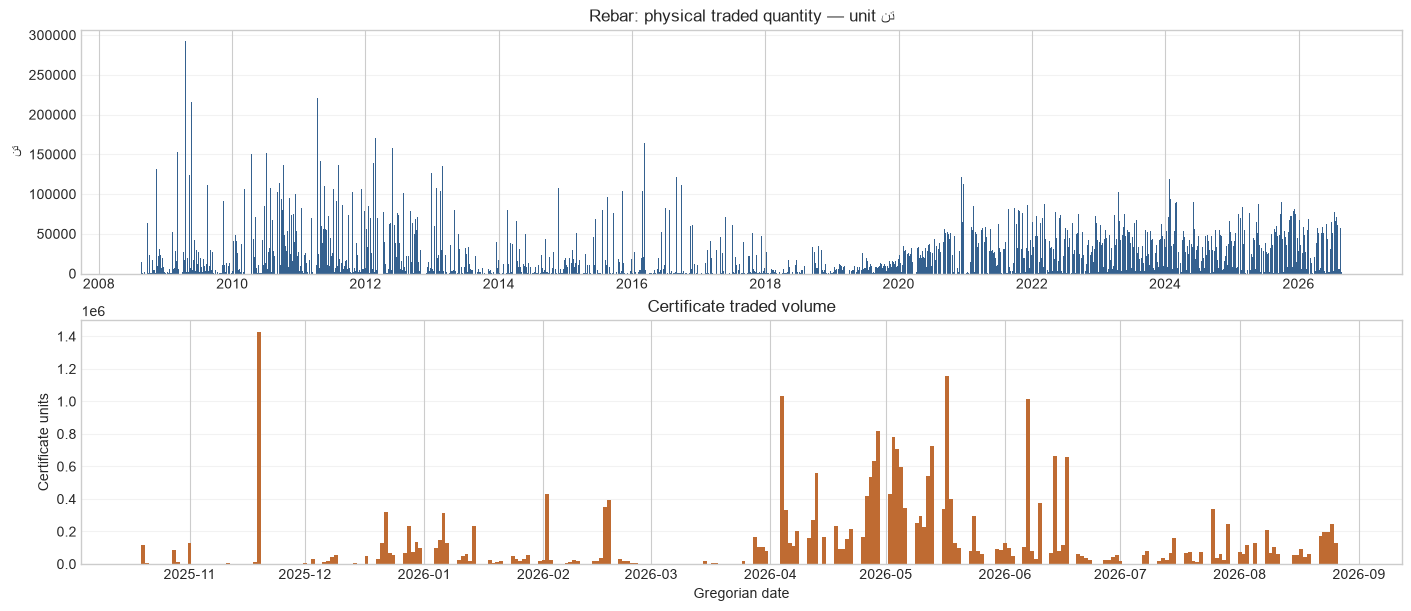

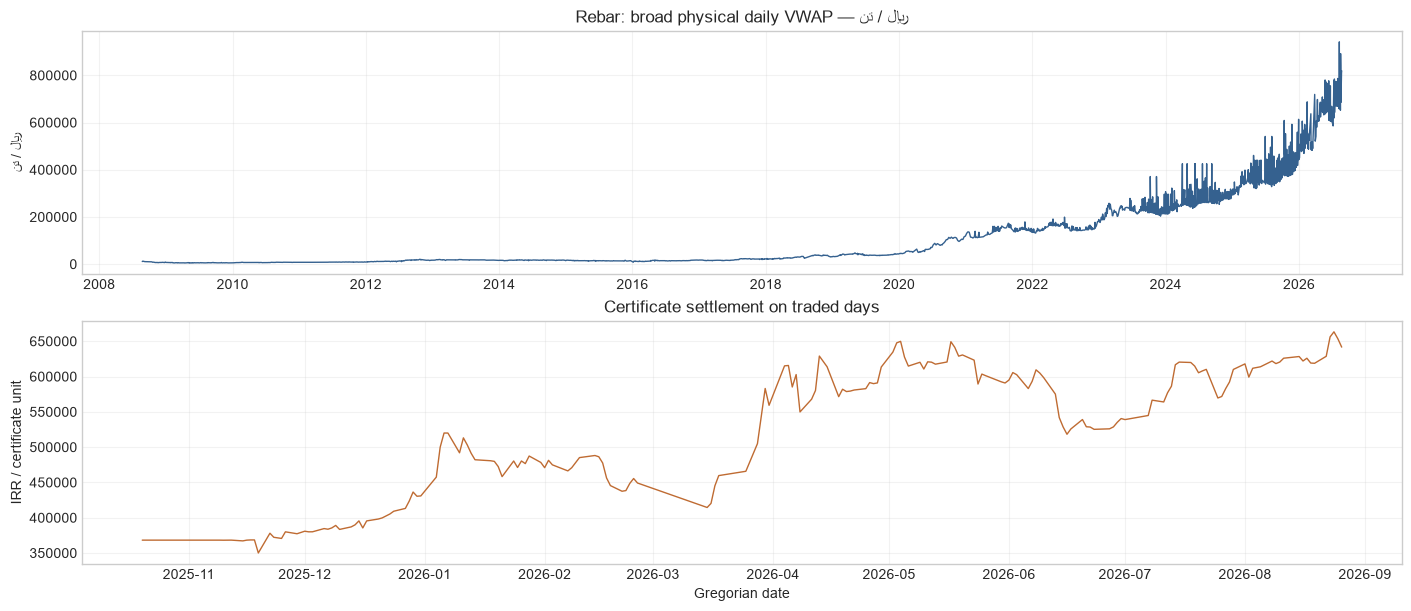

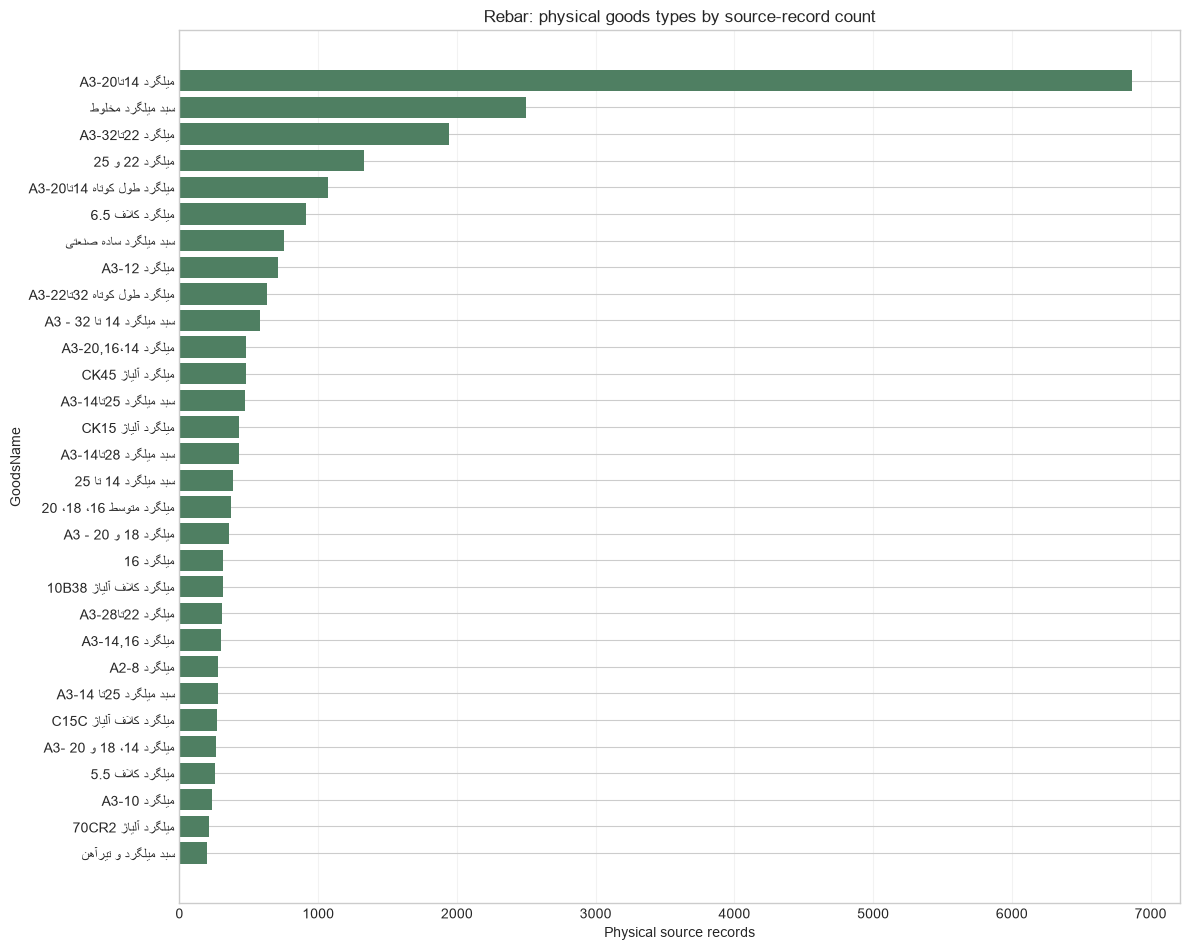

Distinct physical GoodsName labels: 630; records counted: 31,532


,goods_name,record_count,share_pct
0,میلگرد 14تا20-A3,6868,21.781048
1,سبد میلگرد مخلوط,2497,7.918939
2,میلگرد 22تا32-A3,1940,6.152480
3,میلگرد 22 و 25,1332,4.224280
4,میلگرد طول کوتاه 14تا20-A3,1073,3.402892
...,...,...,...
625,میلگرد طول کوتاه 14 و 20 - A3,1,0.003171
626,میلگرد 32-A3,1,0.003171
627,میلگرد کلاف 7-SAE1008,1,0.003171
628,میلگرد A3-8,1,0.003171


No validated processed bubble dataset exists. No bubble was calculated or inferred in this notebook.


In [6]:
from pathlib import Path
import sys

def locate_workspace(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / "commodity" / "rebar").exists() and (candidate / "shared").exists():
            return candidate
    raise FileNotFoundError("Could not locate workspace root")

WORKSPACE_ROOT = locate_workspace()
if str(WORKSPACE_ROOT) not in sys.path:
    sys.path.insert(0, str(WORKSPACE_ROOT))

from shared.notebook_tools.commodity_dashboard import (
    goods_type_counts,
    load_markets,
    market_summary,
    plot_available_bubbles,
    plot_goods_type_counts,
    plot_market_prices,
    plot_trade_activity,
)

PROJECT_DIR = WORKSPACE_ROOT / "commodity" / "rebar"
physical_dashboard, certificate_dashboard = load_markets(
    PROJECT_DIR, "rebar", physical_filename=None
)
display(market_summary(physical_dashboard, certificate_dashboard))
plot_trade_activity(physical_dashboard, certificate_dashboard, "Rebar")
plot_market_prices(physical_dashboard, certificate_dashboard, "Rebar")
goods_count_table = plot_goods_type_counts(physical_dashboard, "Rebar", top_n=30)
display(goods_count_table)
bubble_series_plotted = plot_available_bubbles(PROJECT_DIR, "Rebar")